# 02 Roboflow Dataset Audit

Roboflow에서 내려받은 YOLO11 형식 ZIP 2개를 학습 전에 검수함.

이번 노트북의 목적은 학습이 아니라, 아래를 확인하는 것임.

- clean v1, light augmentation v2 ZIP이 정상적인 YOLO dataset 구조인지 확인함.
- `data.yaml`의 클래스 순서가 우리가 의도한 6개 클래스와 맞는지 확인함.
- train/valid/test 이미지와 라벨 개수가 맞는지 확인함.
- 라벨 누락 이미지가 있으면 어떤 파일인지 찾음.
- bounding box 좌표가 YOLO 형식으로 정상 범위 안에 있는지 확인함.
- class별 분포와 bbox overlay 샘플을 보고, 바로 학습으로 넘어가도 되는지 판단함.

여기서 이상이 없으면 다음 노트북에서 YOLO11n 학습으로 넘어감.


## 0. 실행 설정

이 노트북은 local VSCode `<env>` kernel에서 실행함.

입력 ZIP은 아래 폴더에 있다고 가정함.

```text
~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset
```

압축 해제 결과와 검수 산출물은 `10_experiments/07_sign_detection_yolo` 아래에 생성함.


In [1]:
from pathlib import Path
import json
import zipfile
import re
from datetime import datetime

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r'~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization')
EXP_ROOT = PROJECT_ROOT / '10_experiments' / '07_sign_detection_yolo'
ZIP_ROOT = PROJECT_ROOT / '20_shared_assets' / 'dataset'
DATASET_ROOT = EXP_ROOT / 'datasets' / 'roboflow_exports'
REVIEW_ROOT = EXP_ROOT / 'review_outputs' / '02_roboflow_dataset_audit'
TABLE_DIR = REVIEW_ROOT / 'tables'
GRID_DIR = REVIEW_ROOT / 'grids'

for p in [DATASET_ROOT, TABLE_DIR, GRID_DIR]:
    p.mkdir(parents=True, exist_ok=True)

EXPECTED_CLASSES = ['horn', 'left', 'right', 'speed_20', 'stop', 'straight']
SPLITS = ['train', 'valid', 'test']
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

print('PROJECT_ROOT:', PROJECT_ROOT)
print('EXP_ROOT:', EXP_ROOT)
print('ZIP_ROOT:', ZIP_ROOT)
print('DATASET_ROOT:', DATASET_ROOT)
print('REVIEW_ROOT:', REVIEW_ROOT)


PROJECT_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization
EXP_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo
ZIP_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset
DATASET_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\datasets\roboflow_exports
REVIEW_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\02_roboflow_dataset_audit


## 1. ZIP 파일 확인

Roboflow에서 받은 ZIP 2개를 자동으로 찾음.

- `no_aug`가 들어간 ZIP은 clean baseline dataset으로 봄.
- `light`, `blur`, `rotate`, `noise` 등이 들어간 ZIP은 light augmentation dataset으로 봄.


In [2]:
zips = sorted(ZIP_ROOT.glob('*.zip'))
print('zip files:', len(zips))
for z in zips:
    print(f'- {z.name} ({z.stat().st_size / 1024 / 1024:.2f} MB)')

assert zips, f'No zip files found in {ZIP_ROOT}'

def infer_dataset_key(zip_path: Path) -> str:
    name = zip_path.name.lower()
    if 'no_aug' in name or 'clean' in name or 'v1-' in name:
        return 'clean_v1'
    if 'light' in name or 'aug' in name or 'blur' in name or 'rotate' in name or 'noise' in name or 'v2-' in name:
        return 'light_aug_v2'
    return zip_path.stem

zip_records = []
for z in zips:
    zip_records.append({
        'dataset_key': infer_dataset_key(z),
        'zip_name': z.name,
        'zip_path': str(z),
        'size_mb': z.stat().st_size / 1024 / 1024,
    })
zip_df = pd.DataFrame(zip_records)
display(zip_df)

assert zip_df['dataset_key'].is_unique, 'dataset_key가 중복됨. ZIP 이름을 확인해야 함.'


zip files: 2
- 26-1_Embedded_sign_labeling.v1-field2_sign_640_no_aug.yolov11.zip (49.49 MB)
- 26-1_Embedded_sign_labeling.v2-field2_sign_640_light_blur_rotate_noise.yolov11.zip (125.88 MB)


,dataset_key,zip_name,zip_path,size_mb
0,clean_v1,26-1_Embedded_sign_labeling.v1-field2_sign_640...,~\02_Projects\University\26-1_Em...,49.490909
1,light_aug_v2,26-1_Embedded_sign_labeling.v2-field2_sign_640...,~\02_Projects\University\26-1_Em...,125.876238


## 2. ZIP 내부 구조와 `data.yaml` 확인

YOLO dataset은 보통 아래 구조를 가져야 함.

```text
train/images/*.jpg
train/labels/*.txt
valid/images/*.jpg
valid/labels/*.txt
test/images/*.jpg
test/labels/*.txt
data.yaml
```

`data.yaml`의 `names` 순서가 곧 YOLO class id와 연결됨.  
예를 들어 `names[0] == horn`이면 label txt의 첫 숫자 `0`은 horn을 뜻함.


In [3]:
def read_zip_text(zip_path: Path, entry_name: str) -> str | None:
    with zipfile.ZipFile(zip_path, 'r') as zf:
        try:
            with zf.open(entry_name) as f:
                return f.read().decode('utf-8')
        except KeyError:
            return None

# PyYAML이 없어도 names/nc 정도는 읽을 수 있게 가볍게 파싱함.
def parse_data_yaml_text(text: str) -> dict:
    result = {}
    for line in text.splitlines():
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        if line.startswith('nc:'):
            result['nc'] = int(line.split(':', 1)[1].strip())
        elif line.startswith('names:'):
            raw = line.split(':', 1)[1].strip()
            names = re.findall(r"['\"]([^'\"]+)['\"]", raw)
            if not names and raw.startswith('['):
                names = [x.strip() for x in raw.strip('[]').split(',') if x.strip()]
            result['names'] = names
        elif ':' in line and not line.startswith('roboflow'):
            k, v = line.split(':', 1)
            result[k.strip()] = v.strip()
    return result

zip_structure_rows = []
yaml_rows = []
for rec in zip_records:
    zip_path = Path(rec['zip_path'])
    with zipfile.ZipFile(zip_path, 'r') as zf:
        names = zf.namelist()
        for split in SPLITS:
            img_count = sum(1 for n in names if n.startswith(f'{split}/images/') and Path(n).suffix.lower() in IMAGE_EXTS)
            label_count = sum(1 for n in names if n.startswith(f'{split}/labels/') and n.endswith('.txt'))
            zip_structure_rows.append({
                'dataset_key': rec['dataset_key'],
                'split': split,
                'images_in_zip': img_count,
                'labels_in_zip': label_count,
                'delta_images_minus_labels': img_count - label_count,
            })
    yaml_text = read_zip_text(zip_path, 'data.yaml')
    assert yaml_text is not None, f'data.yaml missing: {zip_path.name}'
    parsed = parse_data_yaml_text(yaml_text)
    yaml_rows.append({
        'dataset_key': rec['dataset_key'],
        'nc': parsed.get('nc'),
        'names': parsed.get('names'),
        'train': parsed.get('train'),
        'val': parsed.get('val'),
        'test': parsed.get('test'),
    })

structure_df = pd.DataFrame(zip_structure_rows)
yaml_df = pd.DataFrame(yaml_rows)

display(yaml_df)
display(structure_df)

for _, row in yaml_df.iterrows():
    assert row['nc'] == 6, row.to_dict()
    assert row['names'] == EXPECTED_CLASSES, f"class names mismatch: {row['dataset_key']} {row['names']}"

structure_df.to_csv(TABLE_DIR / 'zip_structure_counts.csv', index=False, encoding='utf-8-sig')
yaml_df.to_csv(TABLE_DIR / 'data_yaml_summary.csv', index=False, encoding='utf-8-sig')
print('saved:', TABLE_DIR / 'zip_structure_counts.csv')


,dataset_key,nc,names,train,val,test
0,clean_v1,6,"[horn, left, right, speed_20, stop, straight]",../train/images,../valid/images,../test/images
1,light_aug_v2,6,"[horn, left, right, speed_20, stop, straight]",../train/images,../valid/images,../test/images


,dataset_key,split,images_in_zip,labels_in_zip,delta_images_minus_labels
0,clean_v1,train,2034,2034,0
1,clean_v1,valid,254,254,0
2,clean_v1,test,254,254,0
3,light_aug_v2,train,4068,4068,0
4,light_aug_v2,valid,254,254,0
5,light_aug_v2,test,254,254,0


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\02_roboflow_dataset_audit\tables\zip_structure_counts.csv


## 3. 압축 해제

ZIP을 실험 폴더 아래 `datasets/roboflow_exports/{dataset_key}`에 해제함.

이미 해제되어 있으면 기본적으로 재사용함.  
다시 풀고 싶으면 `FORCE_EXTRACT = True`로 바꿔 실행하면 됨.


In [4]:
FORCE_EXTRACT = False

extracted_records = []
for rec in zip_records:
    zip_path = Path(rec['zip_path'])
    dataset_key = rec['dataset_key']
    out_dir = DATASET_ROOT / dataset_key
    marker = out_dir / 'data.yaml'
    if FORCE_EXTRACT and out_dir.exists():
        import shutil
        shutil.rmtree(out_dir)
    if not marker.exists():
        out_dir.mkdir(parents=True, exist_ok=True)
        print('extracting:', zip_path.name, '->', out_dir)
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(out_dir)
    else:
        print('reuse extracted:', out_dir)
    extracted_records.append({
        'dataset_key': dataset_key,
        'dataset_dir': str(out_dir),
        'data_yaml': str(out_dir / 'data.yaml'),
    })

extracted_df = pd.DataFrame(extracted_records)
display(extracted_df)
extracted_df.to_csv(TABLE_DIR / 'extracted_dataset_paths.csv', index=False, encoding='utf-8-sig')


extracting: 26-1_Embedded_sign_labeling.v1-field2_sign_640_no_aug.yolov11.zip -> ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\datasets\roboflow_exports\clean_v1
extracting: 26-1_Embedded_sign_labeling.v2-field2_sign_640_light_blur_rotate_noise.yolov11.zip -> ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\datasets\roboflow_exports\light_aug_v2


,dataset_key,dataset_dir,data_yaml
0,clean_v1,~\02_Projects\University\26-1_Em...,~\02_Projects\University\26-1_Em...
1,light_aug_v2,~\02_Projects\University\26-1_Em...,~\02_Projects\University\26-1_Em...


## 4. 이미지/라벨 매칭 검사

각 split에서 다음을 확인함.

- 이미지가 있는데 label txt가 없는 경우
- label txt가 있는데 이미지가 없는 경우
- label txt는 있지만 빈 파일인 경우

일반적인 표지판 탐지 데이터셋이라면 모든 이미지에 박스가 1개 이상 있는 것이 자연스러움.  
다만 Roboflow에서 의도적으로 negative/background 이미지를 포함했다면 빈 라벨도 가능함. 이번 field2 sign pack은 표지판 클래스 폴더에서 만든 것이므로, label 누락은 우선 확인 대상임.


In [5]:
def collect_split_files(dataset_dir: Path, split: str):
    image_dir = dataset_dir / split / 'images'
    label_dir = dataset_dir / split / 'labels'
    images = sorted([p for p in image_dir.glob('*') if p.suffix.lower() in IMAGE_EXTS]) if image_dir.exists() else []
    labels = sorted(label_dir.glob('*.txt')) if label_dir.exists() else []
    image_by_stem = {p.stem: p for p in images}
    label_by_stem = {p.stem: p for p in labels}
    return images, labels, image_by_stem, label_by_stem

match_rows = []
missing_label_rows = []
orphan_label_rows = []
empty_label_rows = []

for rec in extracted_records:
    dataset_key = rec['dataset_key']
    dataset_dir = Path(rec['dataset_dir'])
    for split in SPLITS:
        images, labels, image_by_stem, label_by_stem = collect_split_files(dataset_dir, split)
        image_stems = set(image_by_stem)
        label_stems = set(label_by_stem)
        missing = sorted(image_stems - label_stems)
        orphan = sorted(label_stems - image_stems)
        empty = [stem for stem, p in label_by_stem.items() if p.stat().st_size == 0]
        match_rows.append({
            'dataset_key': dataset_key,
            'split': split,
            'image_count': len(images),
            'label_count': len(labels),
            'missing_label_count': len(missing),
            'orphan_label_count': len(orphan),
            'empty_label_count': len(empty),
        })
        for stem in missing:
            missing_label_rows.append({
                'dataset_key': dataset_key,
                'split': split,
                'stem': stem,
                'image_path': str(image_by_stem[stem]),
            })
        for stem in orphan:
            orphan_label_rows.append({
                'dataset_key': dataset_key,
                'split': split,
                'stem': stem,
                'label_path': str(label_by_stem[stem]),
            })
        for stem in empty:
            empty_label_rows.append({
                'dataset_key': dataset_key,
                'split': split,
                'stem': stem,
                'label_path': str(label_by_stem[stem]),
                'image_path': str(image_by_stem.get(stem, '')),
            })

match_df = pd.DataFrame(match_rows)
missing_label_df = pd.DataFrame(missing_label_rows)
orphan_label_df = pd.DataFrame(orphan_label_rows)
empty_label_df = pd.DataFrame(empty_label_rows)

display(match_df)
if len(missing_label_df):
    print('missing label images')
    display(missing_label_df)
if len(orphan_label_df):
    print('orphan labels')
    display(orphan_label_df)
if len(empty_label_df):
    print('empty labels')
    display(empty_label_df)

match_df.to_csv(TABLE_DIR / 'image_label_match_summary.csv', index=False, encoding='utf-8-sig')
missing_label_df.to_csv(TABLE_DIR / 'missing_label_images.csv', index=False, encoding='utf-8-sig')
orphan_label_df.to_csv(TABLE_DIR / 'orphan_labels.csv', index=False, encoding='utf-8-sig')
empty_label_df.to_csv(TABLE_DIR / 'empty_labels.csv', index=False, encoding='utf-8-sig')
print('saved match tables to:', TABLE_DIR)


,dataset_key,split,image_count,label_count,missing_label_count,orphan_label_count,empty_label_count
0,clean_v1,train,2034,2034,0,0,1
1,clean_v1,valid,254,254,0,0,0
2,clean_v1,test,254,254,0,0,0
3,light_aug_v2,train,4068,4068,0,0,2
4,light_aug_v2,valid,254,254,0,0,0
5,light_aug_v2,test,254,254,0,0,0


empty labels


,dataset_key,split,stem,label_path,image_path
0,clean_v1,train,field2_horn_000001_jpg.rf.2aeb67017abb5350efc3...,~\02_Projects\University\26-1_Em...,~\02_Projects\University\26-1_Em...
1,light_aug_v2,train,field2_horn_000001_jpg.rf.15c09232e1347a318697...,~\02_Projects\University\26-1_Em...,~\02_Projects\University\26-1_Em...
2,light_aug_v2,train,field2_horn_000001_jpg.rf.2aeb67017abb5350efc3...,~\02_Projects\University\26-1_Em...,~\02_Projects\University\26-1_Em...


saved match tables to: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\02_roboflow_dataset_audit\tables


## 5. YOLO label 값 범위와 클래스 분포 검사

YOLO label txt의 한 줄은 아래 형식임.

```text
class_id x_center y_center width height
```

좌표는 이미지 크기에 대해 0~1로 정규화되어 있어야 함.  
여기서는 label 값이 범위를 벗어나지 않는지, class id가 0~5 안에 있는지, class별 box 수가 어느 정도인지 확인함.


In [6]:
def parse_yolo_label_file(label_path: Path):
    rows = []
    text = label_path.read_text(encoding='utf-8').strip()
    if not text:
        return rows
    for line_no, line in enumerate(text.splitlines(), start=1):
        parts = line.split()
        row = {'line_no': line_no, 'raw': line}
        if len(parts) != 5:
            row.update({'parse_ok': False, 'issue': 'not_5_columns'})
        else:
            try:
                cls = int(float(parts[0]))
                vals = [float(x) for x in parts[1:]]
                row.update({
                    'parse_ok': True,
                    'class_id': cls,
                    'x_center': vals[0],
                    'y_center': vals[1],
                    'width': vals[2],
                    'height': vals[3],
                    'issue': '',
                })
            except Exception as e:
                row.update({'parse_ok': False, 'issue': f'parse_error:{type(e).__name__}'})
        rows.append(row)
    return rows

label_rows = []
issue_rows = []

for rec in extracted_records:
    dataset_key = rec['dataset_key']
    dataset_dir = Path(rec['dataset_dir'])
    for split in SPLITS:
        _, labels, image_by_stem, _ = collect_split_files(dataset_dir, split)
        for label_path in labels:
            parsed_rows = parse_yolo_label_file(label_path)
            for parsed in parsed_rows:
                stem = label_path.stem
                image_path = image_by_stem.get(stem)
                row = {
                    'dataset_key': dataset_key,
                    'split': split,
                    'stem': stem,
                    'label_path': str(label_path),
                    'image_path': str(image_path) if image_path else '',
                    **parsed,
                }
                if row.get('parse_ok'):
                    cls = row['class_id']
                    vals = [row['x_center'], row['y_center'], row['width'], row['height']]
                    issue = []
                    if not (0 <= cls < len(EXPECTED_CLASSES)):
                        issue.append('class_id_out_of_range')
                    if any(v < 0 or v > 1 for v in vals):
                        issue.append('coord_out_of_0_1')
                    if row['width'] <= 0 or row['height'] <= 0:
                        issue.append('non_positive_wh')
                    if row['width'] < 0.005 or row['height'] < 0.005:
                        issue.append('very_tiny_box')
                    if row['width'] > 0.9 or row['height'] > 0.9:
                        issue.append('very_large_box')
                    row['class_name'] = EXPECTED_CLASSES[cls] if 0 <= cls < len(EXPECTED_CLASSES) else 'INVALID'
                    row['issue'] = ';'.join(issue)
                label_rows.append(row)
                if row.get('issue'):
                    issue_rows.append(row)

labels_df = pd.DataFrame(label_rows)
label_issues_df = pd.DataFrame(issue_rows)

display(labels_df.head(10))
print('total boxes:', len(labels_df))
print('label issues:', len(label_issues_df))
if len(label_issues_df):
    display(label_issues_df.head(50))

class_count_df = labels_df.groupby(['dataset_key', 'split', 'class_id', 'class_name']).size().reset_index(name='box_count')
display(class_count_df)

labels_df.to_csv(TABLE_DIR / 'all_yolo_boxes.csv', index=False, encoding='utf-8-sig')
label_issues_df.to_csv(TABLE_DIR / 'label_value_issues.csv', index=False, encoding='utf-8-sig')
class_count_df.to_csv(TABLE_DIR / 'class_distribution_by_split.csv', index=False, encoding='utf-8-sig')
print('saved:', TABLE_DIR / 'class_distribution_by_split.csv')


,dataset_key,split,stem,label_path,image_path,line_no,raw,parse_ok,class_id,x_center,y_center,width,height,issue,class_name
0,clean_v1,train,field2_horn_000002_jpg.rf.94094066c969633f37fa...,~\02_Projects\University\26-1_Em...,~\02_Projects\University\26-1_Em...,1,0 0.6643518518518519 0.37101851851851847 0.058...,True,0,0.664352,0.371019,0.058951,0.065484,,horn
1,clean_v1,train,field2_horn_000003_jpg.rf.397e970046cd91c96b1e...,~\02_Projects\University\26-1_Em...,~\02_Projects\University\26-1_Em...,1,0 0.6654320987654321 0.36937242798353903 0.046...,True,0,0.665432,0.369372,0.046914,0.058909,,horn
2,clean_v1,train,field2_horn_000004_jpg.rf.6314a05baa7156af9c85...,~\02_Projects\University\26-1_Em...,~\02_Projects\University\26-1_Em...,1,0 0.662962962962963 0.36998971193415636 0.0543...,True,0,0.662963,0.369990,0.054321,0.064259,,horn
3,clean_v1,train,field2_horn_000005_jpg.rf.c260b85b026ce242f9d1...,~\02_Projects\University\26-1_Em...,~\02_Projects\University\26-1_Em...,1,0 0.6643518518518519 0.3687551440329218 0.0540...,True,0,0.664352,0.368755,0.054012,0.070021,,horn
4,clean_v1,train,field2_horn_000006_jpg.rf.2924afd2c1c313a1d006...,~\02_Projects\University\26-1_Em...,~\02_Projects\University\26-1_Em...,1,0 0.665895061728395 0.3718415637860082 0.05092...,True,0,0.665895,0.371842,0.050926,0.063848,,horn
5,clean_v1,train,field2_horn_000007_jpg.rf.407c58ef9415d37d11a7...,~\02_Projects\University\26-1_Em...,~\02_Projects\University\26-1_Em...,1,0 0.6691358024691358 0.3666975308641975 0.0691...,True,0,0.669136,0.366698,0.069136,0.070844,,horn
6,clean_v1,train,field2_horn_000008_jpg.rf.b5dfdb98aefb40cdfa9c...,~\02_Projects\University\26-1_Em...,~\02_Projects\University\26-1_Em...,1,0 0.6685185185185184 0.36402263374485594 0.040...,True,0,0.668519,0.364023,0.040741,0.056451,,horn
7,clean_v1,train,field2_horn_000010_jpg.rf.852ce888de17d7b3f8e8...,~\02_Projects\University\26-1_Em...,~\02_Projects\University\26-1_Em...,1,0 0.6749999999999999 0.3636111111111111 0.0475...,True,0,0.675000,0.363611,0.047531,0.063848,,horn
8,clean_v1,train,field2_horn_000011_jpg.rf.e37027d8f680829ac0ca...,~\02_Projects\University\26-1_Em...,~\02_Projects\University\26-1_Em...,1,0 0.6734567901234567 0.3644341563786008 0.0506...,True,0,0.673457,0.364434,0.050617,0.065494,,horn
9,clean_v1,train,field2_horn_000012_jpg.rf.9b1b09170413800c3776...,~\02_Projects\University\26-1_Em...,~\02_Projects\University\26-1_Em...,1,0 0.6708333333333333 0.3662860082304526 0.0484...,True,0,0.670833,0.366286,0.048457,0.065082,,horn


total boxes: 7117
label issues: 2


,dataset_key,split,stem,label_path,image_path,line_no,raw,parse_ok,class_id,x_center,y_center,width,height,issue,class_name
0,clean_v1,valid,field2_horn_000456_jpg.rf.c6566a2fe8c141e436fd...,~\02_Projects\University\26-1_Em...,~\02_Projects\University\26-1_Em...,1,0 0.6094135802469135 0.34223251028806584 0.006...,True,0,0.609414,0.342233,0.006481,0.00463,very_tiny_box,horn
1,light_aug_v2,valid,field2_horn_000456_jpg.rf.c6566a2fe8c141e436fd...,~\02_Projects\University\26-1_Em...,~\02_Projects\University\26-1_Em...,1,0 0.6094135802469135 0.34223251028806584 0.006...,True,0,0.609414,0.342233,0.006481,0.00463,very_tiny_box,horn


,dataset_key,split,class_id,class_name,box_count
0,clean_v1,test,0,horn,42
1,clean_v1,test,1,left,49
2,clean_v1,test,2,right,44
3,clean_v1,test,3,speed_20,51
4,clean_v1,test,4,stop,39
5,clean_v1,test,5,straight,29
6,clean_v1,train,0,horn,368
7,clean_v1,train,1,left,374
8,clean_v1,train,2,right,325
9,clean_v1,train,3,speed_20,327


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\02_roboflow_dataset_audit\tables\class_distribution_by_split.csv


## 6. bbox overlay 샘플 확인

숫자 검사는 통과해도, 사람이 그린 박스가 실제 표지판 본체를 잘 감싸는지 확인해야 함.

정책:

- 박스는 표지판의 사각형 본체만 감싸는 것이 목표임.
- 기둥/받침대/배경은 포함하지 않는 것이 좋음.
- 아주 조금의 여백은 괜찮지만, 표지판 밖 배경이 너무 많이 들어가면 좋지 않음.

아래 셀은 class별 샘플 overlay grid를 저장하고 화면에도 보여줌.


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\02_roboflow_dataset_audit\grids\train_class_sample_overlay_grid.jpg


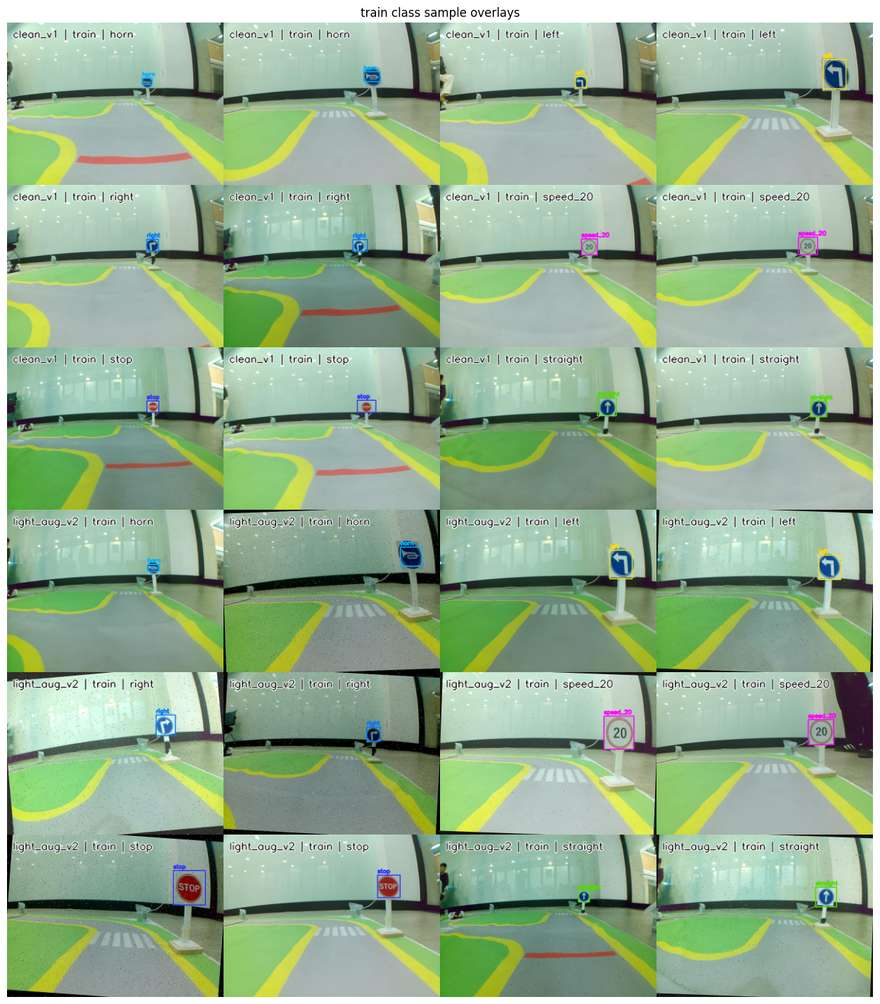

WindowsPath('~/02_Projects/University/26-1_EmbeddedArtificialSystemOptimization/10_experiments/07_sign_detection_yolo/review_outputs/02_roboflow_dataset_audit/grids/train_class_sample_overlay_grid.jpg')

In [7]:
CLASS_COLORS = {
    'horn': (255, 180, 0),
    'left': (0, 220, 255),
    'right': (255, 120, 0),
    'speed_20': (255, 0, 255),
    'stop': (255, 50, 50),
    'straight': (0, 220, 80),
}

def draw_yolo_boxes(image_bgr, label_path: Path, names=EXPECTED_CLASSES):
    img = image_bgr.copy()
    h, w = img.shape[:2]
    for row in parse_yolo_label_file(label_path):
        if not row.get('parse_ok'):
            continue
        cls = row['class_id']
        if not (0 <= cls < len(names)):
            continue
        name = names[cls]
        xc, yc, bw, bh = row['x_center'], row['y_center'], row['width'], row['height']
        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w - 1, x2), min(h - 1, y2)
        color = CLASS_COLORS.get(name, (0, 255, 0))
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, name, (x1, max(20, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2, cv2.LINE_AA)
    return img

def make_overlay_grid(samples_df: pd.DataFrame, out_path: Path, title: str, cols=4, tile_w=320):
    samples = samples_df.to_dict('records')
    if not samples:
        print('no samples for', title)
        return None
    thumbs = []
    for row in samples:
        image_path = Path(row['image_path'])
        label_path = Path(row['label_path'])
        img = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        if img is None:
            continue
        img = draw_yolo_boxes(img, label_path)
        h, w = img.shape[:2]
        scale = tile_w / w
        tile_h = int(h * scale)
        img = cv2.resize(img, (tile_w, tile_h), interpolation=cv2.INTER_AREA)
        label = f"{row['dataset_key']} | {row['split']} | {row['class_name']}"
        cv2.putText(img, label, (8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 2, cv2.LINE_AA)
        cv2.putText(img, label, (8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1, cv2.LINE_AA)
        thumbs.append(img)
    if not thumbs:
        return None
    rows = int(np.ceil(len(thumbs) / cols))
    tile_h = max(t.shape[0] for t in thumbs)
    canvas = np.full((rows * tile_h, cols * tile_w, 3), 245, dtype=np.uint8)
    for i, t in enumerate(thumbs):
        r, c = divmod(i, cols)
        canvas[r*tile_h:r*tile_h+t.shape[0], c*tile_w:c*tile_w+t.shape[1]] = t
    out_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(out_path), canvas)
    print('saved:', out_path)
    plt.figure(figsize=(16, max(4, rows * 3)))
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()
    return out_path

rng = np.random.default_rng(7)

# clean/aug 각각 train에서 class별 2장씩 샘플링
sample_rows = []
for dataset_key in labels_df['dataset_key'].unique():
    train_df = labels_df[(labels_df['dataset_key'] == dataset_key) & (labels_df['split'] == 'train')]
    for cls_name in EXPECTED_CLASSES:
        cls_df = train_df[train_df['class_name'] == cls_name].drop_duplicates('image_path')
        if len(cls_df) == 0:
            continue
        take = min(2, len(cls_df))
        idx = rng.choice(cls_df.index.to_numpy(), size=take, replace=False)
        sample_rows.extend(cls_df.loc[idx].to_dict('records'))

sample_overlay_df = pd.DataFrame(sample_rows)
sample_overlay_df.to_csv(TABLE_DIR / 'overlay_sample_rows.csv', index=False, encoding='utf-8-sig')
make_overlay_grid(sample_overlay_df, GRID_DIR / 'train_class_sample_overlay_grid.jpg', 'train class sample overlays', cols=4)


## 7. 라벨 누락/빈 라벨 이미지 확인

앞에서 누락 라벨이나 빈 라벨이 발견되었다면, 해당 이미지를 직접 확인함.

만약 실제 표지판이 보이는 이미지인데 label이 비어 있으면 Roboflow에서 해당 이미지를 수정하거나, 학습 전에 제외해야 함.  
만약 표지판이 없는 배경 이미지라면 negative sample로 둘 수 있지만, 이번 field2 sign pack의 의도와는 다르므로 별도 판단이 필요함.


problem image rows: 3


,dataset_key,split,stem,label_path,image_path,problem_type
0,clean_v1,train,field2_horn_000001_jpg.rf.2aeb67017abb5350efc3...,~\02_Projects\University\26-1_Em...,~\02_Projects\University\26-1_Em...,empty_label
1,light_aug_v2,train,field2_horn_000001_jpg.rf.15c09232e1347a318697...,~\02_Projects\University\26-1_Em...,~\02_Projects\University\26-1_Em...,empty_label
2,light_aug_v2,train,field2_horn_000001_jpg.rf.2aeb67017abb5350efc3...,~\02_Projects\University\26-1_Em...,~\02_Projects\University\26-1_Em...,empty_label


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\07_sign_detection_yolo\review_outputs\02_roboflow_dataset_audit\grids\missing_or_empty_label_images.jpg


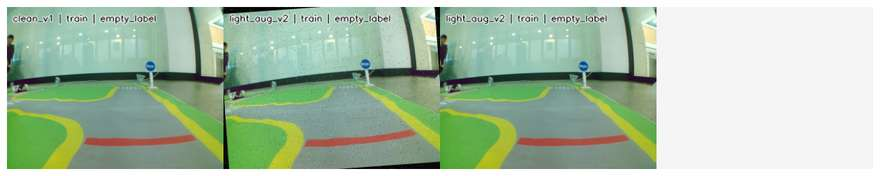

In [8]:
problem_rows = []
if len(missing_label_df):
    for _, row in missing_label_df.iterrows():
        problem_rows.append({**row.to_dict(), 'problem_type': 'missing_label', 'label_path': ''})
if len(empty_label_df):
    for _, row in empty_label_df.iterrows():
        problem_rows.append({**row.to_dict(), 'problem_type': 'empty_label'})

problem_df = pd.DataFrame(problem_rows)
print('problem image rows:', len(problem_df))
if len(problem_df):
    display(problem_df)
    thumbs = []
    for row in problem_rows[:32]:
        image_path = Path(row.get('image_path', ''))
        img = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        if img is None:
            continue
        h, w = img.shape[:2]
        tile_w = 320
        tile_h = int(h * tile_w / w)
        img = cv2.resize(img, (tile_w, tile_h), interpolation=cv2.INTER_AREA)
        text = f"{row['dataset_key']} | {row['split']} | {row['problem_type']}"
        cv2.putText(img, text, (8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,255,255), 2, cv2.LINE_AA)
        cv2.putText(img, text, (8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,0,0), 1, cv2.LINE_AA)
        thumbs.append(img)
    if thumbs:
        cols = 4
        rows = int(np.ceil(len(thumbs) / cols))
        tile_w = 320
        tile_h = max(t.shape[0] for t in thumbs)
        canvas = np.full((rows * tile_h, cols * tile_w, 3), 245, dtype=np.uint8)
        for i, t in enumerate(thumbs):
            r, c = divmod(i, cols)
            canvas[r*tile_h:r*tile_h+t.shape[0], c*tile_w:c*tile_w+t.shape[1]] = t
        out_path = GRID_DIR / 'missing_or_empty_label_images.jpg'
        cv2.imwrite(str(out_path), canvas)
        print('saved:', out_path)
        plt.figure(figsize=(16, max(4, rows * 3)))
        plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()
else:
    print('missing/empty labels 없음. 이 항목은 통과로 봐도 됨.')


## 8. clean v1과 light-aug v2 관계 확인

Roboflow 증강 버전은 보통 train split만 늘어나고 valid/test는 원본 유지되는 형태임.

여기서는 stem에서 Roboflow hash 뒤쪽을 제거하여 clean과 aug의 split 구성을 대략 비교함.


In [9]:
def base_id_from_roboflow_stem(stem: str) -> str:
    # field2_stop_000193_jpg.rf.abcdef -> field2_stop_000193_jpg
    return stem.split('.rf.')[0]

base_rows = []
for rec in extracted_records:
    dataset_key = rec['dataset_key']
    dataset_dir = Path(rec['dataset_dir'])
    for split in SPLITS:
        images, labels, image_by_stem, label_by_stem = collect_split_files(dataset_dir, split)
        for img in images:
            base_rows.append({
                'dataset_key': dataset_key,
                'split': split,
                'stem': img.stem,
                'base_id': base_id_from_roboflow_stem(img.stem),
                'image_path': str(img),
                'has_label': img.stem in label_by_stem,
            })
base_df = pd.DataFrame(base_rows)

base_summary = base_df.groupby(['dataset_key', 'split']).agg(
    image_count=('stem', 'count'),
    unique_base_count=('base_id', 'nunique'),
    labeled_image_count=('has_label', 'sum'),
).reset_index()
display(base_summary)

if set(base_df['dataset_key']) >= {'clean_v1', 'light_aug_v2'}:
    compare_rows = []
    for split in SPLITS:
        clean_set = set(base_df[(base_df['dataset_key']=='clean_v1') & (base_df['split']==split)]['base_id'])
        aug_set = set(base_df[(base_df['dataset_key']=='light_aug_v2') & (base_df['split']==split)]['base_id'])
        compare_rows.append({
            'split': split,
            'clean_base_count': len(clean_set),
            'aug_base_count': len(aug_set),
            'intersection': len(clean_set & aug_set),
            'clean_only': len(clean_set - aug_set),
            'aug_only': len(aug_set - clean_set),
        })
    compare_df = pd.DataFrame(compare_rows)
    display(compare_df)
    compare_df.to_csv(TABLE_DIR / 'clean_vs_aug_base_id_compare.csv', index=False, encoding='utf-8-sig')

base_summary.to_csv(TABLE_DIR / 'base_id_split_summary.csv', index=False, encoding='utf-8-sig')
base_df.to_csv(TABLE_DIR / 'image_base_id_manifest.csv', index=False, encoding='utf-8-sig')


,dataset_key,split,image_count,unique_base_count,labeled_image_count
0,clean_v1,test,254,254,254
1,clean_v1,train,2034,2034,2034
2,clean_v1,valid,254,254,254
3,light_aug_v2,test,254,254,254
4,light_aug_v2,train,4068,2034,4068
5,light_aug_v2,valid,254,254,254


,split,clean_base_count,aug_base_count,intersection,clean_only,aug_only
0,train,2034,2034,2034,0,0
1,valid,254,254,254,0,0
2,test,254,254,254,0,0


## 9. 학습 진행 여부 판단표 생성

아래 기준으로 판단함.

- `data.yaml` class names가 6개 클래스와 일치해야 함.
- label value issue가 0개여야 함.
- missing/empty label은 0개가 가장 좋음. 있으면 사람이 실제 이미지를 보고 수정/제외 여부를 결정해야 함.
- overlay 샘플에서 bbox가 표지판 본체를 대체로 잘 감싸야 함.

노트북 실행 후 아래 summary를 보고 다음 노트북으로 넘어갈지 판단함.


In [10]:
summary = {
    'created_at': datetime.now().isoformat(timespec='seconds'),
    'zip_files': zip_records,
    'expected_classes': EXPECTED_CLASSES,
    'structure': match_df.to_dict('records'),
    'label_issue_count': int(len(label_issues_df)),
    'missing_label_count': int(len(missing_label_df)),
    'empty_label_count': int(len(empty_label_df)),
    'orphan_label_count': int(len(orphan_label_df)),
    'class_distribution_rows': class_count_df.to_dict('records'),
    'output_tables': str(TABLE_DIR),
    'output_grids': str(GRID_DIR),
}
summary_path = TABLE_DIR / 'audit_summary.json'
summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')

print(json.dumps({
    'label_issue_count': summary['label_issue_count'],
    'missing_label_count': summary['missing_label_count'],
    'empty_label_count': summary['empty_label_count'],
    'orphan_label_count': summary['orphan_label_count'],
    'tables': str(TABLE_DIR),
    'grids': str(GRID_DIR),
}, ensure_ascii=False, indent=2))

if summary['label_issue_count'] == 0 and summary['missing_label_count'] == 0 and summary['empty_label_count'] == 0 and summary['orphan_label_count'] == 0:
    print('\n판단: 구조상 바로 학습 노트북으로 넘어가도 됨. overlay만 눈으로 최종 확인하면 됨.')
else:
    print('\n판단: 학습 전 확인 필요. missing/empty/orphan/label issue table과 grid를 먼저 봐야 함.')


{
  "label_issue_count": 2,
  "missing_label_count": 0,
  "empty_label_count": 3,
  "orphan_label_count": 0,
  "tables": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\07_sign_detection_yolo\\review_outputs\\02_roboflow_dataset_audit\\tables",
  "grids": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\07_sign_detection_yolo\\review_outputs\\02_roboflow_dataset_audit\\grids"
}

판단: 학습 전 확인 필요. missing/empty/orphan/label issue table과 grid를 먼저 봐야 함.


## 10. 실행 결과 메모

아직 실행 전이므로 최종 판단은 비워둠.

실행 후 확인할 것:

- `image_label_match_summary.csv`에서 누락/빈 라벨 개수 확인
- `label_value_issues.csv`가 비어 있는지 확인
- `train_class_sample_overlay_grid.jpg`에서 bbox가 표지판 본체에 잘 맞는지 확인
- 문제가 없으면 `03_train_yolo11n_colab.ipynb`에서 clean v1과 light-aug v2를 각각 학습함.
